In [1]:
from src.market.yahoo_finance.market_engine import YahooFinanceMarketEngine
from src.genetic_alghoritm.genetic_algorithm import GeneticAlgorithm
from src.genetic_alghoritm.island_model import IslandModelGeneticAlgorithm
from src.usecases.fundamentalist import FundamentalistChromosome
from src.usecases.volatility import TripleRiskEfficiencyChromosome
from src.backtester.holder_backtester import HolderBacktester
from src.market.yahoo_finance.normalizer import normalize_market_frame
from src.allocation.balanced import BalancedAllocation

In [2]:
import matplotlib.pyplot as plt

In [3]:
tickers = [
        "PETR4.SA",
        "VALE3.SA",
        "ITUB4.SA",
        "BBDC4.SA",
        "ABEV3.SA",
        "B3SA3.SA",
        "BBAS3.SA",
        "GGBR4.SA",
        "RENT3.SA",
        "SUZB3.SA",
        "LREN3.SA",
        "WEGE3.SA",
        "RADL3.SA",
        "HYPE3.SA",
        "UGPA3.SA",
    ]

In [4]:
engine = YahooFinanceMarketEngine(
    tickers, "2023-01-01", "2024-01-01", risk_free_rate=0.05
)


[*********************100%***********************]  15 of 15 completed


In [5]:
random_assets_combinations = [engine.get_random_assets_wallet(
    tickers=tickers,
    max_assets=7
) for _ in range(50)]

map_key_to_fundamental_data = engine.get_multiple_fundamentalist_data(tickers)

fundamentalist_chromosomes = [
    FundamentalistChromosome(
        tickers=asset_combination,
        fundamental_scores=map_key_to_fundamental_data,
    )
    for asset_combination in random_assets_combinations
]

isga_fundamentalist: IslandModelGeneticAlgorithm[FundamentalistChromosome] = (
    IslandModelGeneticAlgorithm(
        initial_population=fundamentalist_chromosomes,
        threshold=0.8,
        max_generations=10,
        mutation_chance=0.1,
        crossover_chance=0.7,
    )
)
result_fundamentalist: list[FundamentalistChromosome] = isga_fundamentalist.run()


Generation 0 Best 0.24501812077828666 Avg 0.19046301908989033
Generation 1 Best 0.24501812077828666 Avg 0.22351822197030077
Generation 2 Best 0.24665081264255334 Avg 0.2262954598997846
Generation 3 Best 0.24665081264255334 Avg 0.22745689319307402
Generation 4 Best 0.24665081264255323 Avg 0.2308093298825275
Generation 5 Best 0.24665081264255323 Avg 0.21613998266673504
Generation 6 Best 0.24665081264255323 Avg 0.21189330193341735
Generation 7 Best 0.2480213875475975 Avg 0.23515062527899858
Generation 8 Best 0.2480213875475975 Avg 0.23923017373894245
Generation 9 Best 0.2480213875475975 Avg 0.22947532487976882
Generation 0 Best 0.21645343602942657 Avg 0.19398601237040367
Generation 1 Best 0.23728597768324547 Avg 0.21102210291236376
Generation 2 Best 0.24229429289282142 Avg 0.22272231036306603
Generation 3 Best 0.2624346840925045 Avg 0.23873645880065325
Generation 4 Best 0.2624346840925045 Avg 0.2381540821019525
Generation 5 Best 0.2624346840925045 Avg 0.23798265529235743
Generation 6 Best

In [6]:
fundamentalist_ratio = [chromossome.fitness() for chromossome in result_fundamentalist]
wallets_in_fundamentalist_result = [chromossome.tickers for chromossome in result_fundamentalist]

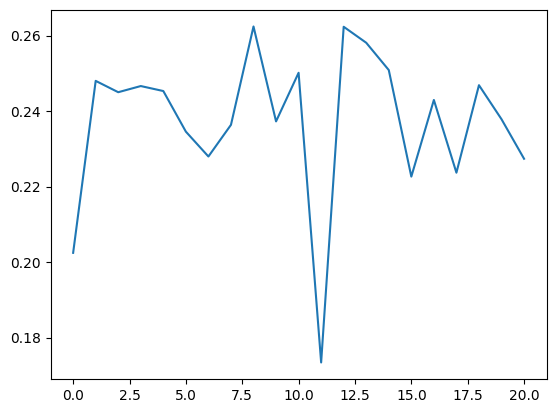

In [7]:
plt.plot(fundamentalist_ratio)

In [8]:
best_wallet = max(
    result_fundamentalist,
    key=lambda chromosome: chromosome.fitness(),
)

random_distribuited_wallets = [YahooFinanceMarketEngine.get_random_distribuited_wallet(
    wallet=best_wallet.tickers, total_number_of_stocks=100
) for _ in range(50)]

initial_generation = [
    TripleRiskEfficiencyChromosome(wallet, engine, 0.05)
    for wallet in random_distribuited_wallets
] 

isga: IslandModelGeneticAlgorithm[TripleRiskEfficiencyChromosome] = (
    IslandModelGeneticAlgorithm(
        initial_population=initial_generation,
        threshold=1.10,
        max_generations=10,
        mutation_chance=0.1,
        crossover_chance=0.7,
    )
)
result: list[TripleRiskEfficiencyChromosome] = isga.run()


Generation 0 Best 0.813937385902024 Avg 0.36792713682558104
Generation 0 Best 0.3950029608847302 Avg 0.25773820747092796
Generation 0 Best 0.784924159861138 Avg 0.3920071042378055
Generation 1 Best 0.813937385902024 Avg 0.5377450335248095
Generation 0 Best 0.573581020340756 Avg 0.3137413271885325
Generation 0 Best 0.7884494616822801 Avg 0.3752298136307259
Generation 1 Best 0.5778219341485181 Avg 0.3689388357624264
Generation 2 Best 0.9877163532491557 Avg 0.818603531393744
Generation 1 Best 0.9761355830499547 Avg 0.717032917578427
Generation 2 Best 0.8430670107822724 Avg 0.41641592845046826
Generation 1 Best 0.5724810902019583 Avg 0.5072040709120884
Generation 2 Best 1.1784969144647648 Avg 0.924925482343548
Generation 1 Best 0.7971797470047914 Avg 0.6034698349246783
Generation 3 Best 1.0208578291366588 Avg 0.9582084398819846
Generation 2 Best 0.6064774035463103 Avg 0.5670373544938906
Generation 3 Best 0.8978267588224322 Avg 0.5897016875423715
Generation 4 Best 1.0260524879643063 Avg 0.9

In [14]:
returns_from_ga = []
volatility_from_ga = []
for wallet in result:
    print(f"Carteira: {wallet._stocks}")
    backtester = HolderBacktester(
        market_frame=engine.stock_history,
        market_frame_normalizer=normalize_market_frame,
        initial_investment=10000.0,
        wallet=wallet._stocks,
        allocation_strategy_engine=BalancedAllocation(
            wallet._stocks, 500.00
        )
    )
    backtester.run_backtest()
    metrics = backtester.get_performance_metrics()
    print(f"Resultados do backtest: {metrics}")
    print("---------------------")
    volatility_from_ga.append(metrics["volatility"])
    returns_from_ga.append(round(metrics["total_return"],2))

Carteira: [Stock(ticker='ABEV3.SA', amount=np.float64(45.0)), Stock(ticker='UGPA3.SA', amount=np.float64(325.0)), Stock(ticker='B3SA3.SA', amount=np.float64(3.0)), Stock(ticker='RADL3.SA', amount=np.float64(147.0)), Stock(ticker='LREN3.SA', amount=np.float64(73.0)), Stock(ticker='WEGE3.SA', amount=6)]


/home/felipe-nicoletti/Projetos/genetic-alghoritm-portfolio-otimization/src/market/yahoo_finance/normalizer.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  market_frame.fillna(method="ffill").fillna(method="bfill")


Resultados do backtest: {'initial_value': np.float64(10000.0), 'final_value': np.float64(15652.07887172699), 'total_return': np.float64(0.565207887172699), 'mean_return': np.float64(0.0019006671761122786), 'volatility': 0.01312797119678102}
---------------------
Carteira: [Stock(ticker='ABEV3.SA', amount=np.float64(27.0)), Stock(ticker='UGPA3.SA', amount=np.float64(336.0)), Stock(ticker='B3SA3.SA', amount=np.float64(25.0)), Stock(ticker='RADL3.SA', amount=np.float64(155.0)), Stock(ticker='LREN3.SA', amount=np.float64(57.0)), Stock(ticker='WEGE3.SA', amount=4)]
Resultados do backtest: {'initial_value': np.float64(10000.0), 'final_value': np.float64(15971.984671592712), 'total_return': np.float64(0.5971984671592713), 'mean_return': np.float64(0.001984383009114164), 'volatility': 0.01325435037379404}
---------------------
Carteira: [Stock(ticker='ABEV3.SA', amount=np.float64(44.0)), Stock(ticker='UGPA3.SA', amount=np.float64(304.0)), Stock(ticker='B3SA3.SA', amount=np.float64(33.0)), Stoc

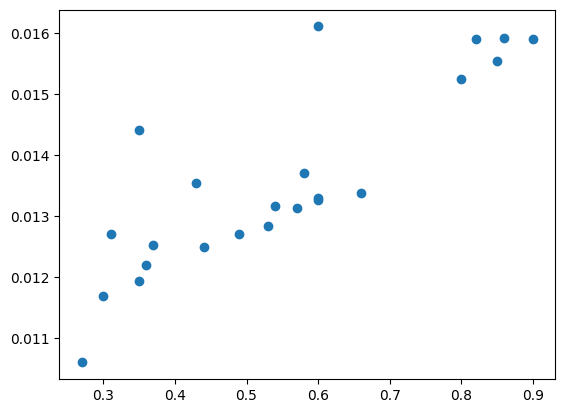

In [15]:
plt.scatter(returns_from_ga, volatility_from_ga)